In [1]:
import math
import numpy as np
import SimpleITK as sitk
import pyvista as pv
import point_cloud_utils as pcu

from morphometry import hip, utils
from matplotlib import pyplot as plt
from scipy.spatial import KDTree
from sklearn.cluster import KMeans
from pathlib import Path

In [2]:
import importlib
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [3]:
pv.set_jupyter_backend('trame')

# Femoral head center

In [4]:
mask = sitk.ReadImage('/home/simon/Data/Hamburg/100016_30_PD_FS_SPC_COR FK/Segmentation_12.seg.nrrd')
spacing = mask.GetSpacing()
z_ratio = abs(spacing[2]) / 2 * abs(spacing[0])

In [5]:
mask_array = sitk.GetArrayFromImage(mask)
mask_array = np.where(mask_array == 1, 1, 0)

In [6]:
mask_array.shape

(160, 264, 384)

Axis order: z = coronal, y = axial, z = sagittal

In [7]:
mask_array = np.swapaxes(mask_array, 0, 1)

In [8]:
r, c = hip.get_femoral_head_center(mask_array, z_ratio)

In [9]:
r, c

(22.327326010646942, (169, 60, 105))

In [10]:
point_cloud = np.argwhere(mask_array)
idx = pcu.downsample_point_cloud_poisson_disk(point_cloud.astype('float32'), radius=0, target_num_samples=1000)

In [10]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(np.argwhere(mask_array)), color='b')
p.add_mesh(pv.Sphere(22, (169, 60, 105)))
p.enable_eye_dome_lighting()
p.show()

/home/simon/Work/morpohmetry/venv/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:42219/index.html?ui=P_0x7f9c698ceda0_0&reconnect=auto" class="pyvi…

# Femoral shaft axis

In [11]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [12]:
p0, p1 = hip.get_femoral_shaft_axis(mask_array)

In [91]:
p0, p1

(array([261,  50,  80]), array([241,  59,  78]))

In [92]:
p3 = p0 - p1
p3

array([20, -9,  2])

In [94]:
p = pv.Plotter()
p.add_mesh(pv.PolyData(point_cloud[idx]), color='b')
p.add_lines(np.array([np.array(c), point_cloud[73246]]), color='r')
p.add_lines(np.array([p0, p1 - 3 * p3]), color='g')
p.add_lines(np.array([p0, p1]), color='y')
p.add_mesh(pv.Sphere(22, (169, 60, 105)))
p.show()

/home/simon/anaconda3/envs/shapes/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


Widget(value='<iframe src="http://localhost:44947/index.html?ui=P_0x7c29ac1bd360_33&reconnect=auto" class="pyv…

# Femoral neck axis

In [11]:
c, r

((169, 60, 105), 22.327326010646942)

In [12]:
solid_sphere = pv.SolidSphere(inner_radius=1.0*r, outer_radius=1.2 * r, center=c)
points_i_want = np.array(solid_sphere.points)
points_i_want = points_i_want[points_i_want[:, 0] > c[0]]
points_i_want = points_i_want[points_i_want[:, 2] < c[2]]

In [13]:
tmp = pv.PolyData(point_cloud[idx])

/home/simon/Work/morpohmetry/venv/lib/python3.10/site-packages/pyvista/core/utilities/points.py:55: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(


In [14]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(points_i_want), color='r', opacity=0.5)
p.show()

Widget(value='<iframe src="http://localhost:35585/index.html?ui=P_0x77e3cfba7bb0_0&reconnect=auto" class="pyvi…

In [15]:
pc_tree = KDTree(point_cloud)
sphere_tree = KDTree(points_i_want)

In [16]:
pairs = pc_tree.query_ball_tree(sphere_tree, 2)

In [17]:
neck_points = list()
for pair in pairs:
    if len(pair) > 0:
        for index in pair:
            neck_points.append(sphere_tree.data[index])

neck_points = np.array(neck_points)

In [87]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(neck_points), color='r')
p.show()

Widget(value='<iframe src="http://localhost:34757/index.html?ui=P_0x7850582bc220_16&reconnect=auto" class="pyv…

In [18]:
com = KMeans(n_clusters=1).fit(neck_points).cluster_centers_

In [19]:
com

array([[182.60396729,  64.64052133,  89.29559053]])

In [26]:
neck_axis = c - com[0]

In [91]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(neck_points), color='r')
p.add_mesh(pv.Sphere(5, com[0]), color='g')
p.add_lines(np.array([c, com[0] - 3 * neck_axis]), color='y', width=5)
p.show()

Widget(value='<iframe src="http://localhost:34757/index.html?ui=P_0x784c137895a0_17&reconnect=auto" class="pyv…

# CCD

In [57]:
importlib.reload(hip)

<module 'morphometry.hip' from '/home/simon/Work/morpohmetry/morphometry/hip.py'>

In [29]:
r, c = hip.get_femoral_head_center(mask_array, z_ratio)
p0, p1 = hip.get_femoral_shaft_axis(mask_array)
com = hip.get_femoral_neck_axis(mask_array, (r, c))

(60, 106)
36.8 83.2


In [30]:
hip.calc_ccd(c, com, (p0, p1))

115.07718555134898

In [40]:
segmentations = list()
for path in Path('/home/simon/Data/Hamburg').iterdir():
    for file in path.iterdir():
        if 'Segmentation' in file.name:
            segmentations.append(file)

In [41]:
segmentations

[PosixPath('/home/simon/Data/Hamburg/100024_30_PD_FS_SPC_COR FK/Segmentation_20.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100023_30_PD_FS_SPC_COR FK/Segmentation_19.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100012_30_PD_FS_SPC_COR FK/Segmentation_8.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100009_30_PD_FS_SPC_COR FK/Segmentation_5.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100015_30_PD_FS_SPC_COR FK/Segmentation_11.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100006_30_PD_FS_SPC_COR FK/Segmentation_2.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100013_30_PD_FS_SPC_COR FK/Segmentation_9.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100011_30_PD_FS_SPC_COR FK/Segmentation_7.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100020_30_PD_FS_SPC_COR FK/Segmentation_16.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100014_30_PD_FS_SPC_COR FK/Segmentation_10.seg.nrrd'),
 PosixPath('/home/simon/Data/Hamburg/100008_30_PD_FS_SPC_COR FK/Segmentation_4.seg.nr

In [58]:
for seg in segmentations:
    print(seg)
    mask = sitk.ReadImage(str(seg))
    mask_array = sitk.GetArrayFromImage(mask)
    mask_array = np.where(mask_array == 1, 1, 0)
    mask_array = np.swapaxes(mask_array, 0, 1)
    r, c = hip.get_femoral_head_center(mask_array, z_ratio)
    p0, p1 = hip.get_femoral_shaft_axis(mask_array)
    com = hip.get_femoral_neck_axis(mask_array, (r, c))
    print(hip.calc_ccd(c, com, (p0, p1)))

/home/simon/Data/Hamburg/100024_30_PD_FS_SPC_COR FK/Segmentation_20.seg.nrrd
108.57990757252838
/home/simon/Data/Hamburg/100023_30_PD_FS_SPC_COR FK/Segmentation_19.seg.nrrd
117.8250075218648
/home/simon/Data/Hamburg/100012_30_PD_FS_SPC_COR FK/Segmentation_8.seg.nrrd
124.45348292986114
/home/simon/Data/Hamburg/100009_30_PD_FS_SPC_COR FK/Segmentation_5.seg.nrrd
104.48340107972132
/home/simon/Data/Hamburg/100015_30_PD_FS_SPC_COR FK/Segmentation_11.seg.nrrd
109.18258512918443
/home/simon/Data/Hamburg/100006_30_PD_FS_SPC_COR FK/Segmentation_2.seg.nrrd
110.08662238284573
/home/simon/Data/Hamburg/100013_30_PD_FS_SPC_COR FK/Segmentation_9.seg.nrrd
115.61643210490479
/home/simon/Data/Hamburg/100011_30_PD_FS_SPC_COR FK/Segmentation_7.seg.nrrd
105.03754822792452
/home/simon/Data/Hamburg/100020_30_PD_FS_SPC_COR FK/Segmentation_16.seg.nrrd
104.86635748823285
/home/simon/Data/Hamburg/100014_30_PD_FS_SPC_COR FK/Segmentation_10.seg.nrrd
106.14716816355701
/home/simon/Data/Hamburg/100008_30_PD_FS_SPC_C

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

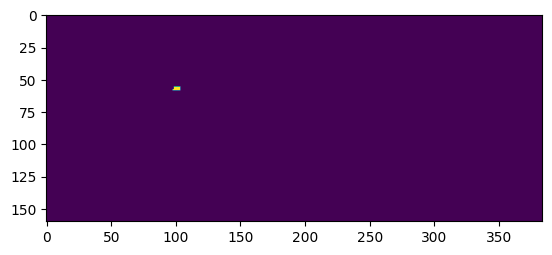

In [54]:
plt.imshow(mask_array[146])

In [53]:
mask_array[146, 59, 100]

np.int64(0)

# Alpha angle

In [20]:
most_proximal_points = neck_points[neck_points[:, 0] == neck_points[:, 0].min()]
most_proximal_lateral_point = most_proximal_points[most_proximal_points[:, 2] == most_proximal_points[:, 2].max()]

In [21]:
most_proximal_lateral_point[0]

array([169.13069179,  57.58953178,  82.80355773])

In [22]:
v1 = c - com[0]
v2 = c - most_proximal_lateral_point[0]
v1, v2

(array([-13.60396729,  -4.64052133,  15.70440947]),
 array([-0.13069179,  2.41046822, 22.19644227]))

In [23]:
v1 /= np.linalg.norm(v1)
v2 /= np.linalg.norm(v2)

In [24]:
angle = np.arccos(np.dot(v1, v2))
math.degrees(angle)

44.475259327347096

In [28]:
p = pv.Plotter()
p.add_mesh(tmp, color='b')
p.add_mesh(pv.PolyData(neck_points), color='r')
p.add_mesh(pv.Sphere(5, com[0]), color='g')
p.add_lines(np.array([c, com[0] - 3 * neck_axis]), color='y', width=5)
p.add_lines(np.array([c, most_proximal_lateral_point[0]]), color='y', width=5)
p.show()

Widget(value='<iframe src="http://localhost:35585/index.html?ui=P_0x77e33442aef0_3&reconnect=auto" class="pyvi…

In [108]:
p.close()